### Configuration and libaries

In [1]:
#Config and Imports
year = "20"
grouped_expenditures_path = f"grouped_expenditures{year}.csv"

# Path to FEC data -- if not included, will be generated
fec_data_path = "./data/"

db_path = f"db_{year}.sqlite3"
nx_graph_path = f"graph_{year}.nx.pickle"

In [52]:
import polars as pl
import pandas as pd
import numpy as np
import networkx as nx

import sqlite3
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler

from math import pi

#Personalized functions
from fec_load import FECDataLoader
from kmeans_cluster_analysis import Kmeans_Cluster_Analysis
from isolation_forests import isolation_forest_analysis

### Setting up Data

Reading expenditure data

In [3]:
# Get grouped expenditures
expenditures = pl.read_csv(grouped_expenditures_path)

In [4]:
expenditures
#The expenditures table has one entry for each payer-payee-expcode-entity type combination.

CRPFilerid,CRPRecipname,Expcode,EntType,City,State,Zip,amount
str,str,str,str,str,str,str,f64
"""N00027503""","""Public Charters""","""A40""","""ORG""","""Avoca""","""PA""","""186412229""",239.0
"""N00037034""","""Reservations.Com""","""A40""","""ORG""","""ORLANDO""","""FL""","""32801 """,418.0
"""N00035431""","""Lynn Museum & Historical Socie…","""A70""","""ORG""","""Lynn""","""MA""","""01901 """,650.0
"""C00193433""","""MJ for Texas""","""R30""","""CCM""","""Berkeley""","""CA""","""94703 """,416.0
"""C00401224""","""Durflinger, Janice""","""N10""","""IND""","""LINCOLN""","""NE""","""68504 """,85.0
…,…,…,…,…,…,…,…
"""C00401224""","""Ligons, Michael""","""N10""","""IND""","""EVERETT""","""WA""","""98208 """,50.0
"""N00029349""","""Ohio Dept of Taxation""","""U00""","""ORG""","""Columbus""","""OH""","""432295404""",223.0
"""N00044985""","""Nash, William""","""N10""","""IND""","""Washington""","""DC""","""200031809""",200.0


Expenditure categories
NB: Categories have overlap (specifically, consulting w/ others) - will need to adjust for visualization component

In [5]:
expcode_totals = expenditures.group_by("CRPFilerid").agg(
    total_expenditures=pl.col("amount").sum(),
    admin=pl.col("amount").filter(pl.col("Expcode").is_in(["A00", "A20", "A30", "A40", "A50", "A60", "A70"])).sum(),
    campaign=pl.col("amount").filter(pl.col("Expcode").is_in(["C10", "C30"])).sum(),
    fundraising=pl.col("amount").filter(pl.col("Expcode").is_in(["F00", "F10", "F20", "F30", "F40", "F50"])).sum(),
    media=pl.col("amount").filter(pl.col("Expcode").is_in(["M00", "M01", "M10", "M20", "M30", "M40", "M50"])).sum(),
    refund_trans=pl.col("amount").filter(pl.col("Expcode").is_in(["N10"])).sum(),
    contrib_trans=pl.col("amount").filter(pl.col("Expcode").is_in(["R00", "R10", "R20", "R30", "R35", "R40", "R50"])).sum(),
    strat_research=pl.col("amount").filter(pl.col("Expcode").is_in(["S10", "S20", "S50"])).sum(),
    unclassifiable=pl.col("amount").filter(pl.col("Expcode").is_in(["U00", "U10", "U20", "U30", "U50", "U60"])).sum(),
    consulting=pl.col("amount").filter(pl.col("Expcode").is_in(["A50", "F50", "M50", "S50", "U50"])).sum(),
    salaries=pl.col("amount").filter(pl.col("Expcode").is_in(["W10"])).sum(),
    transfers=pl.col("amount").filter(pl.col("Expcode").is_in(["T00", "T10", "T20", "T30", "T50"])).sum()
)

In [6]:
# Convert from polars to pandas
expcode_totals = expcode_totals.to_pandas()

### EDA of Expenditure Data

Exploratory Analysis of Expenditure Data
- Every expenditure category has negative values 
- Some negative values. Decided to keep these in.

In [7]:
summary = expcode_totals.describe()
summary

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers
count,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03,9.512000e+03
mean,2.240487e+06,1.000459e+05,9.929110e+04,1.638811e+05,5.930675e+05,2.917488e+04,6.336491e+05,6.147727e+04,1.027300e+05,9.840133e+04,1.305904e+05,2.824907e+05
std,4.530821e+07,1.768841e+06,1.482807e+06,2.794072e+06,1.361839e+07,7.563399e+05,3.681037e+07,8.197198e+05,1.936482e+06,1.255127e+06,1.864533e+06,7.399474e+06
min,-6.741640e+05,-3.264000e+03,-8.360000e+02,-1.166000e+03,-7.652600e+04,-1.000000e+03,-1.500000e+04,-5.450000e+02,-5.914511e+06,-1.393000e+03,-3.741580e+05,-1.300000e+04
25%,1.345925e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.853550e+04,1.650000e+03,0.000000e+00,3.550000e+01,0.000000e+00,0.000000e+00,2.500000e+03,0.000000e+00,1.523000e+03,0.000000e+00,0.000000e+00,0.000000e+00
75%,3.602738e+05,1.413900e+04,8.002500e+02,1.192825e+04,2.294000e+03,1.000000e+03,5.500000e+04,1.200000e+03,1.665900e+04,1.162925e+04,0.000000e+00,0.000000e+00
max,3.635001e+09,1.172759e+08,9.892520e+07,2.200380e+08,8.391031e+08,6.804850e+07,3.523069e+09,4.689127e+07,1.474703e+08,7.669432e+07,8.158383e+07,4.557360e+08


In [9]:
# How many negative values in each column? 
# Unclassifiable has the most negative values but the rest of the columns have a negliable. 
column_indices = list(range(1,13))

negative_counts = expcode_totals.iloc[:, column_indices].apply(lambda x: (x < 0).sum())
print(negative_counts)

total_expenditures    13
admin                  5
campaign               5
fundraising            3
media                  8
refund_trans           1
contrib_trans         25
strat_research         1
unclassifiable        99
consulting             2
salaries               6
transfers              5
dtype: int64


Jitter Plots
- There is a lot of density of points around 0 to 0.5. 
- Potentially a lot of outliers. But will not remove these because could be important for identifying scam PACs.
- Makes it difficult to see any kind of actual distribution.

In [10]:
columns = ['admin', 'campaign', 'fundraising', 'media', 'refund_trans', 'contrib_trans', 'strat_research', 
           'unclassifiable', 'consulting', 'salaries', 'transfers']

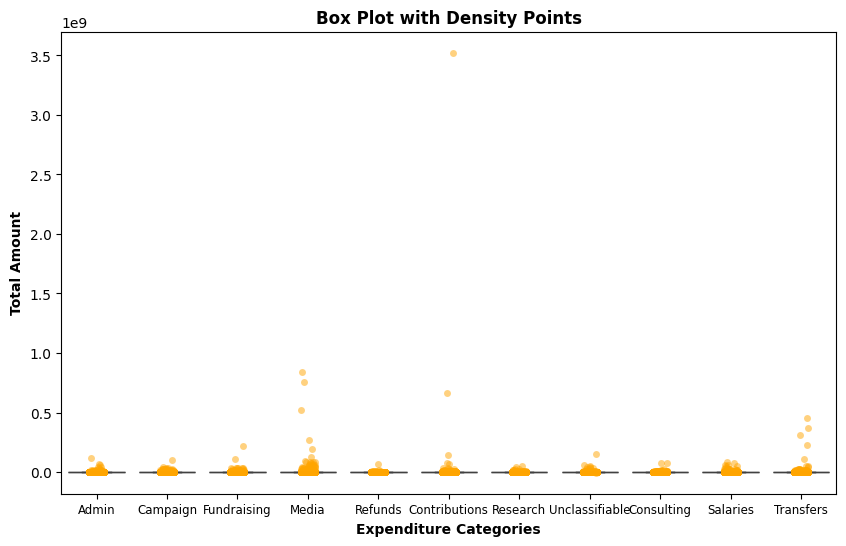

In [12]:
#subset = expcode_totals[expcode_totals[columns].lt(20000000).all(axis=1)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=expcode_totals[columns], color="skyblue", showfliers=False) 
sns.stripplot(data=expcode_totals[columns], color="orange", jitter=True, alpha=0.5)  
new_labels = ['Admin', 'Campaign', 'Fundraising', 'Media', 'Refunds', 'Contributions', 'Research',
                         'Unclassifiable', 'Consulting', 'Salaries', 'Transfers']
plt.xticks(ticks = range(len(new_labels)), labels= new_labels, fontsize = 8.5)
plt.title("Box Plot with Density Points", fontweight = 'bold')
plt.xlabel("Expenditure Categories", fontweight = 'bold')
plt.ylabel("Total Amount", fontweight = 'bold')
plt.show()

### FEC Data

- PAC Summary File
From: https://www.fec.gov/campaign-finance-data/pac-and-party-summary-file-description/ - This one also contains a lot of other columns that could end up being relevant

- This file does NOT contain candidate committees and certain other types of committees - see data notes.

In [13]:
#loading FEC Data
fec = FECDataLoader(fec_data_path)

headers = ["CMTE_ID", "CMTE_NM", "CMTE_TP", "CMTE_DSGN", "CMTE_FILING_FREQ", "TTL_RECEIPTS",
           "TRANS_FROM_AFF", "INDV_CONTRIB", "OTHER_POL_CMTE_CONTRIB", "CAND_CONTRIB", "CAND_LOANS",
           "TTL_LOANS_RECEIVED", "TTL_DISB", "TRANF_TO_AFF", "INDV_REFUNDS", "OTHER_POL_CMTE_REFUNDS",
           "CAND_LOAN_REPAY", "LOAN_REPAY", "COH_BOP", "COH_COP", "DEBTS_OWED_BY", "NONFED_TRANS_RECEIVED",
           "CONTRIB_TO_OTHER_CMTE", "IND_EXP", "PTY_COORD_EXP", "NONFED_SHARE_EXP", "CVG_END_DT"]

# com_master = fec.load(f"https://www.fec.gov/files/bulk-downloads/20{year}/cm{year}.zip", "https://www.fec.gov/files/bulk-downloads/data_dictionaries/cm_header_file.csv").set_index("CMTE_ID")
pac_summary = fec.load(f"https://www.fec.gov/files/bulk-downloads/20{year}/webk{year}.zip", 
                        headers=headers
).set_index("CMTE_ID")

Loading webk20 from disk


In [14]:
#Checking pac summary columns are correct
pac_summary.columns

Index(['CMTE_NM', 'CMTE_TP', 'CMTE_DSGN', 'CMTE_FILING_FREQ', 'TTL_RECEIPTS',
       'TRANS_FROM_AFF', 'INDV_CONTRIB', 'OTHER_POL_CMTE_CONTRIB',
       'CAND_CONTRIB', 'CAND_LOANS', 'TTL_LOANS_RECEIVED', 'TTL_DISB',
       'TRANF_TO_AFF', 'INDV_REFUNDS', 'OTHER_POL_CMTE_REFUNDS',
       'CAND_LOAN_REPAY', 'LOAN_REPAY', 'COH_BOP', 'COH_COP', 'DEBTS_OWED_BY',
       'NONFED_TRANS_RECEIVED', 'CONTRIB_TO_OTHER_CMTE', 'IND_EXP',
       'PTY_COORD_EXP', 'NONFED_SHARE_EXP', 'CVG_END_DT'],
      dtype='object')

Columns of interest to us:
- CMTE_TP = Committee Type (non-qualified vs qualified)
- CMTE_DSGN = Committee Designation
    - 'U' = unauthorized, 
    - 'D' = Leadership PAC, 
    - 'B' = Lobbyist/Registrant PAC
    - 'J' = Joint Fundraiser
    - 'P' = Principal campaign committee of a candidate
- TTL_RECEIPTS = Total receipts
- TTL_DISB = Total disbursements
- INDV_REFUNDS = Refunds to Indviduals 
- CMTE_NM = Committee Name

In [ ]:
pac_summary_cols = pac_summary[['CMTE_NM', 'CMTE_TP', 'CMTE_DSGN', 'TTL_RECEIPTS', 'TTL_DISB', 'INDV_REFUNDS']]

In [16]:
#Setting index
features = expcode_totals.set_index("CRPFilerid")

# True if nonqualified (N, V, or X)
features['nonqualified'] = pac_summary['CMTE_TP'].isin(['N', 'V', 'X'])

# receipts and expenses 
features["receipts"] = pac_summary["TTL_RECEIPTS"]
#features["expenses"] = pac_summary["TTL_DISB"] #believe this is a duplicate row

# Committee type and designation
features["CMTE_TP"] = pac_summary["CMTE_TP"]
features["CMTE_DSGN"] = pac_summary["CMTE_DSGN"]
features["CMTE_NM"] = pac_summary["CMTE_NM"] # need this for comparison later

features

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,nonqualified,receipts,CMTE_TP,CMTE_DSGN,CMTE_NM
CRPFilerid,,,,,,,,,,,,,,,,,
C00570168,40148.0,2362.0,6723.0,580.0,0.0,0.0,9415.0,0.0,21068.0,0.0,0.0,0.0,True,69258.98,N,U,NEWPORT BEACH WOMEN'S DEMOCRATIC CLUB FEDERAL PAC
C00620740,6478.0,2523.0,0.0,937.0,0.0,18.0,3000.0,0.0,0.0,59.0,0.0,0.0,True,23906.95,N,U,BOULE' 1904 PAC
N00043243,5223.0,0.0,0.0,0.0,0.0,0.0,5223.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
C00009936,1265797.0,82884.0,1966.0,0.0,0.0,5736.0,1150900.0,0.0,10061.0,0.0,250.0,0.0,False,1332174.36,Q,B,AMERICAN FEDERATION OF GOVT. EMPL. POLITICAL A...
N00045048,56666.0,5895.0,0.0,1692.0,14537.0,3700.0,0.0,14161.0,13132.0,19161.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C00378216,65250.0,2200.0,0.0,0.0,0.0,0.0,63050.0,0.0,0.0,0.0,0.0,0.0,False,60850.81,Q,U,SUN POLITICAL ACTION COMMITTEE (SUNPAC)
C00760074,5134.0,0.0,0.0,0.0,5134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,8261.10,O,U,FORSYTH COUNTY PATRIOTS
C00760736,22771.0,4280.0,0.0,2291.0,0.0,0.0,11200.0,0.0,5000.0,0.0,0.0,0.0,True,57887.52,N,U,RESIST RECLAIM REBUILD PAC


Dropping NaN's
- The PAC master file has a lot of nulls (doesn't include candidates, for example):

In [17]:
features.isna().sum()

total_expenditures       0
admin                    0
campaign                 0
fundraising              0
media                    0
refund_trans             0
contrib_trans            0
strat_research           0
unclassifiable           0
consulting               0
salaries                 0
transfers                0
nonqualified          3014
receipts              3014
CMTE_TP               3014
CMTE_DSGN             3014
CMTE_NM               3014
dtype: int64

In [18]:
features = features.dropna()
features

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,nonqualified,receipts,CMTE_TP,CMTE_DSGN,CMTE_NM
CRPFilerid,,,,,,,,,,,,,,,,,
C00570168,40148.0,2362.0,6723.0,580.0,0.0,0.0,9415.0,0.0,21068.0,0.0,0.0,0.0,True,69258.98,N,U,NEWPORT BEACH WOMEN'S DEMOCRATIC CLUB FEDERAL PAC
C00620740,6478.0,2523.0,0.0,937.0,0.0,18.0,3000.0,0.0,0.0,59.0,0.0,0.0,True,23906.95,N,U,BOULE' 1904 PAC
C00009936,1265797.0,82884.0,1966.0,0.0,0.0,5736.0,1150900.0,0.0,10061.0,0.0,250.0,0.0,False,1332174.36,Q,B,AMERICAN FEDERATION OF GOVT. EMPL. POLITICAL A...
C00484154,280.0,280.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,500.00,N,U,ASSOCIATION OF ENERGY SERVICE COMPANIES POLITI...
C00566760,80100.0,0.0,0.0,0.0,0.0,0.0,75100.0,0.0,5000.0,0.0,0.0,0.0,False,41251.01,Q,U,RAYONIER ADVANCED MATERIALS INC GOOD GOVERNMEN...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C00378216,65250.0,2200.0,0.0,0.0,0.0,0.0,63050.0,0.0,0.0,0.0,0.0,0.0,False,60850.81,Q,U,SUN POLITICAL ACTION COMMITTEE (SUNPAC)
C00760074,5134.0,0.0,0.0,0.0,5134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,8261.10,O,U,FORSYTH COUNTY PATRIOTS
C00760736,22771.0,4280.0,0.0,2291.0,0.0,0.0,11200.0,0.0,5000.0,0.0,0.0,0.0,True,57887.52,N,U,RESIST RECLAIM REBUILD PAC


Editing format of some variables
- Cateogrical variables cannot be used in clustering. Will bring these back when doing the logistic regression.

In [19]:
#1 = True (non-qualified)
#0 = False
features.loc[:, 'nonqualified'] = features['nonqualified'].astype(int)

In [20]:
features

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,nonqualified,receipts,CMTE_TP,CMTE_DSGN,CMTE_NM
CRPFilerid,,,,,,,,,,,,,,,,,
C00570168,40148.0,2362.0,6723.0,580.0,0.0,0.0,9415.0,0.0,21068.0,0.0,0.0,0.0,1,69258.98,N,U,NEWPORT BEACH WOMEN'S DEMOCRATIC CLUB FEDERAL PAC
C00620740,6478.0,2523.0,0.0,937.0,0.0,18.0,3000.0,0.0,0.0,59.0,0.0,0.0,1,23906.95,N,U,BOULE' 1904 PAC
C00009936,1265797.0,82884.0,1966.0,0.0,0.0,5736.0,1150900.0,0.0,10061.0,0.0,250.0,0.0,0,1332174.36,Q,B,AMERICAN FEDERATION OF GOVT. EMPL. POLITICAL A...
C00484154,280.0,280.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,500.00,N,U,ASSOCIATION OF ENERGY SERVICE COMPANIES POLITI...
C00566760,80100.0,0.0,0.0,0.0,0.0,0.0,75100.0,0.0,5000.0,0.0,0.0,0.0,0,41251.01,Q,U,RAYONIER ADVANCED MATERIALS INC GOOD GOVERNMEN...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C00378216,65250.0,2200.0,0.0,0.0,0.0,0.0,63050.0,0.0,0.0,0.0,0.0,0.0,0,60850.81,Q,U,SUN POLITICAL ACTION COMMITTEE (SUNPAC)
C00760074,5134.0,0.0,0.0,0.0,5134.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8261.10,O,U,FORSYTH COUNTY PATRIOTS
C00760736,22771.0,4280.0,0.0,2291.0,0.0,0.0,11200.0,0.0,5000.0,0.0,0.0,0.0,1,57887.52,N,U,RESIST RECLAIM REBUILD PAC


In [21]:
summary = features.describe()
summary

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,receipts
count,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03,6.498000e+03
mean,2.017043e+06,7.321781e+04,9.205019e+04,1.421213e+05,1.399093e+05,2.503972e+04,9.020266e+05,4.333483e+04,8.754212e+04,6.471720e+04,9.947233e+04,3.875270e+05,2.996259e+06
std,4.962132e+07,1.677281e+06,1.139244e+06,3.248236e+06,3.159679e+06,8.737122e+05,4.453361e+07,7.052420e+05,2.198620e+06,1.097466e+06,1.543990e+06,8.941584e+06,6.454085e+07
min,-1.475900e+04,-3.264000e+03,-1.550000e+02,-1.166000e+03,-7.652600e+04,-1.000000e+03,-1.500000e+04,-5.450000e+02,-5.914511e+06,-1.393000e+03,-3.741580e+05,-4.068000e+03,-2.503000e+04
25%,1.420625e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.760625e+04
50%,6.538400e+04,5.945000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+04,0.000000e+00,2.505000e+02,0.000000e+00,0.000000e+00,0.000000e+00,8.281558e+04
75%,2.665140e+05,6.514000e+03,0.000000e+00,4.749250e+03,0.000000e+00,0.000000e+00,9.100000e+04,0.000000e+00,6.344750e+03,9.750000e+01,0.000000e+00,0.000000e+00,3.366980e+05
max,3.635001e+09,1.172759e+08,3.896208e+07,2.200380e+08,1.895890e+08,6.804850e+07,3.523069e+09,4.022500e+07,1.474703e+08,7.669432e+07,7.699489e+07,4.557360e+08,4.318378e+09


### NetworkX

- Degree Centrality: Nodes with a high degree centrality are considered influential or well-connected. 
- Closeness Centrality: A node with high closeness centrality can reach other nodes in fewer steps.
- Betweness Centrality: A node with high betweeness centrality acts as a bridge in the network and controls the flow of information between different parts of the graph.
- Eigenvector centrality: High eigenvector centrality indicates a node is connected to many other well-connected nodes

In [22]:
with open(nx_graph_path, "rb") as f:
    full_graph = pickle.load(f)

In [23]:
#Centrality measures
degree = nx.degree_centrality(full_graph)

In [24]:
unwieghted_eigenvector  = nx.eigenvector_centrality(full_graph)

In [25]:
weighted_eigenvector = nx.eigenvector_centrality(full_graph, weight = "amount")

In [26]:
page_rank = nx.pagerank(full_graph)

In [27]:
weighted_page_rank = nx.pagerank(full_graph, weight = "amount")

In [28]:
uw_eigen = pd.Series(unwieghted_eigenvector, index=None, name="uw_eigen")
uw_eigen_weighted = pd.Series(weighted_eigenvector, index= None, name="uw_eigen_weighted")

uw_degree = pd.Series(degree, index = None, name = "uw_degree")

uw_page_rank = pd.Series(page_rank, index = None, name = "uw_page_rank")
uw_page_rank_weighted = pd.Series(weighted_page_rank, index = None, name = "uw_page_rank_weighted")

In [29]:
network_features = features.join([uw_degree, uw_eigen, uw_eigen_weighted, uw_page_rank, uw_page_rank_weighted], how="left")

In [33]:
network_features = network_features.dropna()

pd.options.display.float_format = '{:.6f}'.format
summary = network_features.describe()
summary

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,receipts,uw_degree,uw_eigen,uw_eigen_weighted,uw_page_rank,uw_page_rank_weighted
count,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000
mean,2022193.717703,73432.524618,92320.132737,142538.122858,140319.583269,24348.544220,904671.846736,43461.906930,87798.840099,64906.983022,99764.042290,388663.401605,3004243.248211,0.000298,0.001253,0.000107,0.000005,0.000005
std,49693911.035354,1679734.323519,1140902.969685,3252987.226869,3164300.317294,872973.518035,44598844.087315,706271.588667,2201836.823401,1099068.947072,1546243.402391,8954662.150412,64635235.138171,0.000999,0.006700,0.001953,0.000009,0.000008
min,-14759.000000,-3264.000000,-155.000000,-1166.000000,-76526.000000,-1000.000000,-15000.000000,-545.000000,-5914511.000000,-1393.000000,-374158.000000,-4068.000000,-25030.000000,0.000005,0.000000,-0.000001,0.000004,0.000001
25%,14500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17877.000000,0.000023,0.000000,0.000000,0.000004,0.000004
50%,65750.000000,600.000000,0.000000,0.000000,0.000000,0.000000,10000.000000,0.000000,263.000000,0.000000,0.000000,0.000000,83300.000000,0.000069,0.000000,0.000000,0.000004,0.000004
75%,266949.500000,6558.500000,0.000000,4781.000000,0.000000,0.000000,91499.000000,0.000000,6408.000000,185.000000,0.000000,0.000000,337540.165000,0.000241,0.000422,0.000000,0.000005,0.000005
max,3635001168.000000,117275877.000000,38962085.000000,220037963.000000,189588987.000000,68048502.000000,3523069141.000000,40225001.000000,147470330.000000,76694325.000000,76994886.000000,455736000.000000,4318377981.320000,0.039065,0.168697,0.102602,0.000548,0.000356


### Normalizing Data

- Using min / max to normalize the data.
- Formula: (X - Xmin) / (Xmax - Xmin)

In [34]:
scaling_cols =  ['total_expenditures', 'admin', 'campaign', 'fundraising', 'media', 'refund_trans', 'contrib_trans', 'strat_research', 
           'unclassifiable', 'consulting', 'salaries', 'receipts', 'transfers']

scaled_features = network_features.copy()
scaler = MinMaxScaler()
scaled_features.loc[:, scaling_cols] = scaler.fit_transform(scaled_features[scaling_cols])

In [35]:
summary = scaled_features.describe()
summary

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,receipts,uw_degree,uw_eigen,uw_eigen_weighted,uw_page_rank,uw_page_rank_weighted
count,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000
mean,0.000560,0.000654,0.002373,0.000653,0.001143,0.000373,0.000261,0.001094,0.039132,0.000864,0.006125,0.000862,0.000701,0.000298,0.001253,0.000107,0.000005,0.000005
std,0.013671,0.014323,0.029282,0.014784,0.016684,0.012829,0.012659,0.017558,0.014355,0.014330,0.019985,0.019649,0.014967,0.000999,0.006700,0.001953,0.000009,0.000008
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000005,0.000000,-0.000001,0.000004,0.000001
25%,0.000008,0.000028,0.000004,0.000005,0.000403,0.000015,0.000004,0.000014,0.038560,0.000018,0.004836,0.000009,0.000010,0.000023,0.000000,0.000000,0.000004,0.000004
50%,0.000022,0.000033,0.000004,0.000005,0.000403,0.000015,0.000007,0.000014,0.038562,0.000018,0.004836,0.000009,0.000025,0.000069,0.000000,0.000000,0.000004,0.000004
75%,0.000077,0.000084,0.000004,0.000027,0.000403,0.000015,0.000030,0.000014,0.038602,0.000021,0.004836,0.000009,0.000084,0.000241,0.000422,0.000000,0.000005,0.000005
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.039065,0.168697,0.102602,0.000548,0.000356


In [41]:
graph_cols = ['admin', 'campaign', 'fundraising', 'media', 'refund_trans', 'contrib_trans', 'strat_research', 
           'unclassifiable', 'consulting', 'transfers']

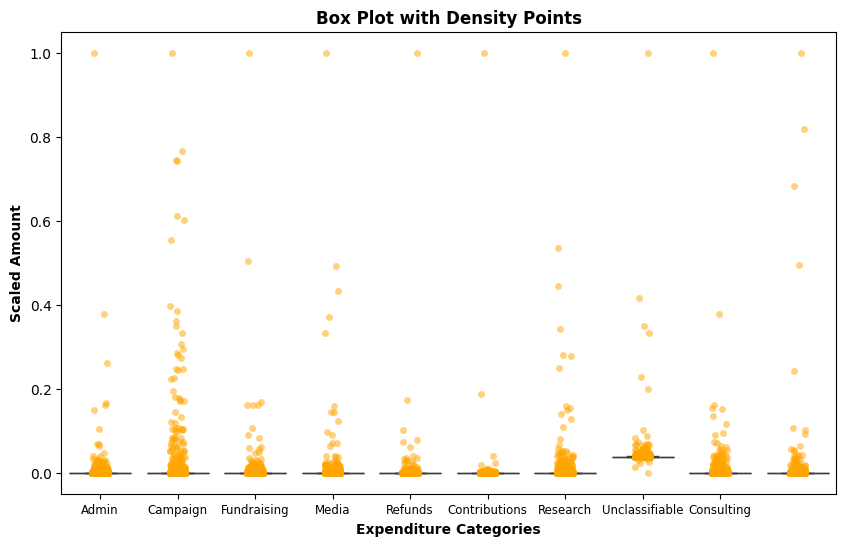

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=scaled_features[graph_cols], color="skyblue", showfliers=False) 
sns.stripplot(data=scaled_features[graph_cols], color="orange", jitter=True, alpha=0.5)  
new_labels = ['Admin', 'Campaign', 'Fundraising', 'Media', 'Refunds', 'Contributions', 'Research',
                         'Unclassifiable', 'Consulting']
plt.xticks(ticks = range(len(new_labels)), labels= new_labels, fontsize = 8.5)
plt.title("Box Plot with Density Points", fontweight = 'bold')
plt.xlabel("Expenditure Categories", fontweight = 'bold')
plt.ylabel("Scaled Amount", fontweight = 'bold')
plt.show()

### Cluster Assumptions

1. Normalize the Data (completed)
2. Independence of features (some possible issues / removal of features needed)
3. Check for outliers (there are obviously outliers - but feel like I shouldn't take these out since they could help identify scam PACs)

In [43]:
#Dropping some columns first because k-means does not do well with binary or categorical data
cluster_checks = scaled_features.copy()
cluster_checks.drop(columns = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM'], inplace=True)

2. Independence of Features
    - Some high correlations among expenditure features 
    - Possible removals:
        - total expenditures
        - refund or contributions
        - salaries, consulting, unclassifiable and/or research

In [44]:
#Calculating correlation max 
corr_matrix = cluster_checks.corr()

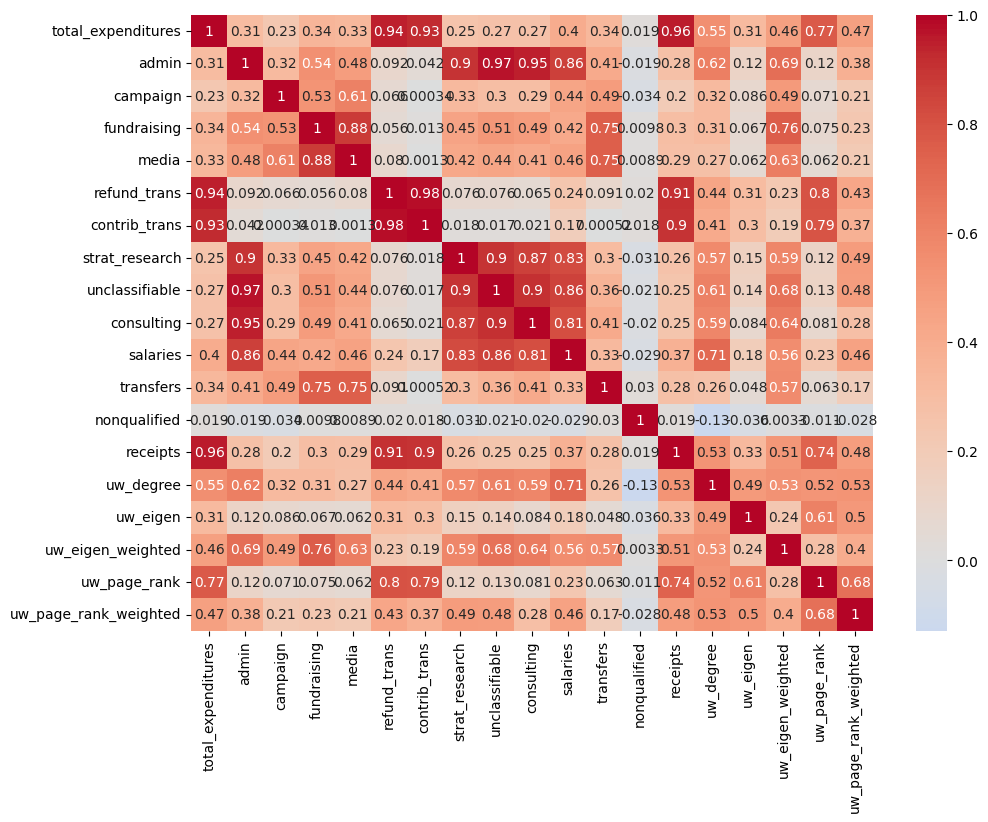

In [45]:
plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.show()

In [46]:
scaled_cleaned = cluster_checks.dropna(axis=0)


In [47]:
summary = scaled_cleaned.describe()
summary

,total_expenditures,admin,campaign,fundraising,media,refund_trans,contrib_trans,strat_research,unclassifiable,consulting,salaries,transfers,receipts,uw_degree,uw_eigen,uw_eigen_weighted,uw_page_rank,uw_page_rank_weighted
count,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000,6479.000000
mean,0.000560,0.000654,0.002373,0.000653,0.001143,0.000373,0.000261,0.001094,0.039132,0.000864,0.006125,0.000862,0.000701,0.000298,0.001253,0.000107,0.000005,0.000005
std,0.013671,0.014323,0.029282,0.014784,0.016684,0.012829,0.012659,0.017558,0.014355,0.014330,0.019985,0.019649,0.014967,0.000999,0.006700,0.001953,0.000009,0.000008
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000005,0.000000,-0.000001,0.000004,0.000001
25%,0.000008,0.000028,0.000004,0.000005,0.000403,0.000015,0.000004,0.000014,0.038560,0.000018,0.004836,0.000009,0.000010,0.000023,0.000000,0.000000,0.000004,0.000004
50%,0.000022,0.000033,0.000004,0.000005,0.000403,0.000015,0.000007,0.000014,0.038562,0.000018,0.004836,0.000009,0.000025,0.000069,0.000000,0.000000,0.000004,0.000004
75%,0.000077,0.000084,0.000004,0.000027,0.000403,0.000015,0.000030,0.000014,0.038602,0.000021,0.004836,0.000009,0.000084,0.000241,0.000422,0.000000,0.000005,0.000005
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.039065,0.168697,0.102602,0.000548,0.000356


### Identifying Potential Scams

Option #1: 
- Use scam PACs identified through online research (i.e, find new sources that identified scam PACs). 

Option #2: 
- Use specific criteria to identify scam PACs. These criteria are listed below. This option is commented out because it didn't yield good results. Option #1 had better results.

Scam Criteria:
- Spend 40% or more on fundraising
- Spend 10% or less on contributions
- Spend 20% or more on consulting
- Are qualified PACs (to exclude PACs that might be just starting / too young)

Option #1

In [ ]:
scam_PACs = ['Conservative Majority Fund', 'Lincoln Fund', 'Patriots for American Leadership', 'Campaign for Conservative Majority',
              'Law Enforcement for a Safer America PAC', 'Grassroots Awareness PAC', 'Autism Awareness PAC', 'American for Law Enforcement PAC',
              'National Campaign PAC', 'Voter Educaiton PAC', 'Action Coalition PAC', 'Protect our Future PAC', 'Life and Liberty PAC',
              'Republican Majority Campaign', 'RightMarch.com PAC', 'American Alliance for Disabled Children PAC', 'American Coalition for Autistic Children',
              'Children\'s Cancer Coalition', 'Feel Bern', 'South Carolina Trump Victory', 'New Jersey Trump Victory' , 'Georgia Trump Victory', 'Americans Socially United',  'Democratic Power Inc.',
              'Democratic Victory PAC, Inc.', 'Democrats United', 'Cops and Kids Together', 'Autism Hear Us Now PAC Inc', 
              'Americans for Police and Trooper Safety','Conservative American Now', 'Tea Party Majority Fund', 'Great America PAC', 
              'Us Veterans Assistance Foundation', 'Firefighters Alliance of America LLC', 'National Assitance Committee', 
              'Standing By Veterans PAC Inc.', 'Heroes United PAC, DBA Volunteer Firefighters Association, DBA Association of Police & First Responders', 
              'Americans for the Cure of Breast Cancer', 'United Veterans Alliance of America PAC Inc,' 'National Campaign PAC', 
              'Americans for Law Enforcement', 'Freedom\'s Defense Fund', 'United Police Officers Association', 
              'Assoication for Emergency Responders and FireFighters PAC, Inc.', 'Put Vets First! PAC & DBA Association for American Veterans', 
              'Republican Majority Campaign', 'Tea Party Leadershsip Fund', 'Patriot Super PAC', 'Conservative Action Fund', 
              'Heart Disease Network of America', 'Community Health Council PAC DBA Breast Cancer Health Council PAC', 'Conservative Freedom Fighters', 
              'Childrens Leukemia Support Network LLC', 'Restore American Freedom and Liberty', 'American Coalition for Injured Veterans PAC', 
              'Remember Mississippi', 'Bold Conservatives PAC', 'VIGOP (Virgin Islands Republican Party)','Tea Party Victory Fund', 
             'Freedomworks for America', 'Volunteer Firefighters and Paramedic Association', 'Law Enforcement for A Safer America PAC', 
              'Conservative Strikforce', 'Conservative Strick Force', 'Police Officers Defense Alliance LLC']

Option #2

In [ ]:
# Percentages of expenditures
#dividing_cols =  ['total_expenditures', 'admin', 'campaign', 'fundraising', 'media', 'refund_trans', 
#                  'contrib_trans', 'strat_research', 'unclassifiable', 'consulting', 'salaries', 'receipts', 
#                  'transfers']

#features.loc[:, dividing_cols] = features.loc[:, dividing_cols].div(features['total_expenditures'], axis = 0) * 100

In [ ]:
#features.loc[:, 'identified_scam'] = np.where(
#    (features.loc[:, 'contrib_trans'] <= 2.0) & (features.loc[:, 'nonqualified'] == 0) 
#    & (features.loc[:, 'fundraising'] >= 43.0)  & (features.loc[:, 'consulting'] >= 19.0),
#    'is_scam',
#    'is_not_scam'
#)

#cross_tab = pd.crosstab(features['identified_scam'], columns = 'count')
#cross_tab


In [ ]:
#scam_PACs = features.loc[features['identified_scam'] == 'is_scam', 'CMTE_NM'].to_list()

Getting known scams PACs to use for stratified sampling in K-means and Isolated Forest

In [98]:
cap_scam_PACs = [s.upper() for s in scam_PACs]
scaled_features['is_known_scam'] = scaled_features['CMTE_NM'].isin(cap_scam_PACs).astype(int)
cross_tab = pd.crosstab(scaled_features['is_known_scam'], columns = 'count')
cross_tab

col_0,count
is_known_scam,
0,6419
1,60


### **K-Means Clustering Summary of Results:**
1. Model with all features (not including categorical but does include binary).
2. Model with all continuous variables - no feature selection completed
3. Model with some removed correlated features.
4. Removing more highly correlated featuers (removing media and reciepts)
5. Removing outliers (all other features included)
6. Removing outliers and all correlated features

**See ML Updates for summary of results**

**Goals for Evualtion Metrics:**
- Silhouette score => Looking for scores close to +1 because the data points are far away from the nearest cluster. This score can range from -1 to 1. A score of -1 means that the data points may have been assigned to the wrong cluster. 
- Inertia => Lower inertia values indicate tighter clustering, meaning that the data points within each cluster are similar to each other. We want lower inertia values. 
- Davies-Bouldin Index => indicates the ratio of within-cluster scatter to between-cluster scatter. A lower DBI indicates better clustering. 
- Elbow method => helps determine the optimal number of clusters by plotting the explained variance (inertia) as a function of the number of clusters. This may be a good tool to see if our data set thinks 2 clusters is optimal. Hopefully so, because we want it to be scam vs non-scam PACs!

**Correlation Issues that may cause problems for the model**
- consulting, admin, salaries, research, and unclassifiable are all highly correlated with each other
    - Also, they are all moderately correlated with uw_degree
- fundraising is only moderately correlated with admin, consulting, research, salaries and unclassifiable
    - It has a small correlation with uw_degree
- salaries is the least correlated with fundraising, so out the four features we will keep salaries. 
- potential features to remove: consulting, admin, research, unclassifable, refunds, total expenditures

#### Model with all Features

In [91]:
cluster_analysis = Kmeans_Cluster_Analysis(scam_PAC_names = scam_PACs)

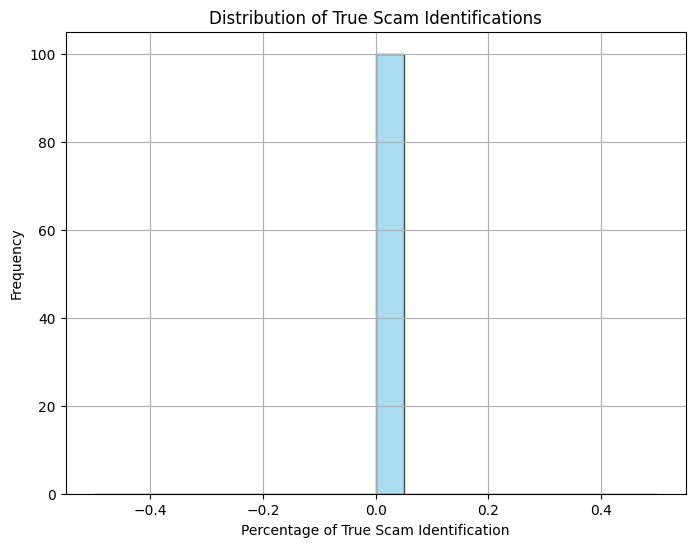

{'average_train_silhouette_score': np.float64(0.99),
 'std_train_silhouette_score': np.float64(0.0),
 'average_train_inertia': np.float64(17.84),
 'std_train_inertia': np.float64(3.87),
 'average_train_davies_bouldin_index': np.float64(0.02),
 'std_train_davies_bouldin_index': np.float64(0.0),
 'average_train_perc_true_scams_identified': np.float64(0.0),
 'std_train_perc_true_scams_identified': np.float64(0.0),
 'average_test_silhouette_score': np.float64(0.99),
 'std_test_silhouette_score': np.float64(0.0),
 'average_test_inertia': np.float64(7.08),
 'std_test_inertia': np.float64(3.87),
 'average_test_davies_bouldin_index': np.float64(0.02),
 'std_test_davies_bouldin_index': np.float64(0.0),
 'average_test_perc_true_scams_identified': np.float64(0.0),
 'std_test_perc_true_scams_identified': np.float64(0.0)}

In [99]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam']

sim_results = cluster_analysis.run_monte_carlo_cluster_model(
    all_scaled_data = scaled_features,
    test_n = 0.3,
    seed = 492,
    features_to_drop = dropped_features,
    n_simulations = 100
)

sim_results

#### Model with all continuous variables (no binary variables)

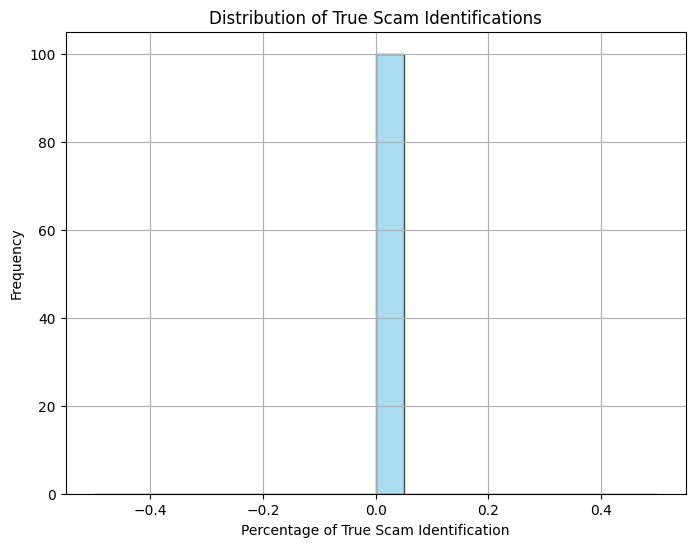

{'average_train_silhouette_score': np.float64(0.99),
 'std_train_silhouette_score': np.float64(0.0),
 'average_train_inertia': np.float64(10.99),
 'std_train_inertia': np.float64(2.71),
 'average_train_davies_bouldin_index': np.float64(0.68),
 'std_train_davies_bouldin_index': np.float64(0.29),
 'average_train_perc_true_scams_identified': np.float64(0.0),
 'std_train_perc_true_scams_identified': np.float64(0.0),
 'average_test_silhouette_score': np.float64(0.99),
 'std_test_silhouette_score': np.float64(0.01),
 'average_test_inertia': np.float64(3.18),
 'std_test_inertia': np.float64(2.24),
 'average_test_davies_bouldin_index': np.float64(0.26),
 'std_test_davies_bouldin_index': np.float64(0.31),
 'average_test_perc_true_scams_identified': np.float64(0.0),
 'std_test_perc_true_scams_identified': np.float64(0.0)}

In [100]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'nonqualified', 'is_known_scam']

sim_results = cluster_analysis.run_monte_carlo_cluster_model(
    all_scaled_data = scaled_features,
    test_n = 0.3,
    seed = 492,
    features_to_drop = dropped_features,
    n_simulations = 100
)

sim_results

#### Model with some correlated features removed
- Features removed: consulting, admin, research, unclassifable, refunds, total expenditures

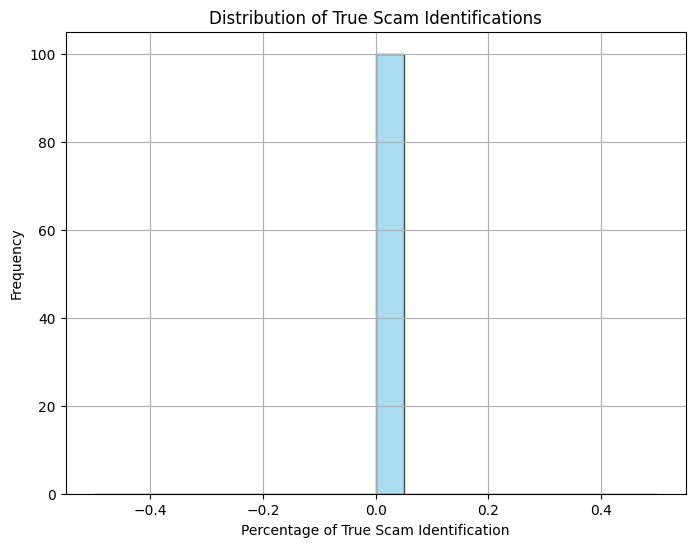

{'average_train_silhouette_score': np.float64(0.99),
 'std_train_silhouette_score': np.float64(0.0),
 'average_train_inertia': np.float64(6.31),
 'std_train_inertia': np.float64(1.36),
 'average_train_davies_bouldin_index': np.float64(0.56),
 'std_train_davies_bouldin_index': np.float64(0.14),
 'average_train_perc_true_scams_identified': np.float64(0.0),
 'std_train_perc_true_scams_identified': np.float64(0.0),
 'average_test_silhouette_score': np.float64(0.99),
 'std_test_silhouette_score': np.float64(0.0),
 'average_test_inertia': np.float64(1.95),
 'std_test_inertia': np.float64(1.23),
 'average_test_davies_bouldin_index': np.float64(0.25),
 'std_test_davies_bouldin_index': np.float64(0.25),
 'average_test_perc_true_scams_identified': np.float64(0.0),
 'std_test_perc_true_scams_identified': np.float64(0.0)}

In [101]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam','nonqualified', 'consulting', 'admin', 'strat_research', 'refund_trans', 'total_expenditures', 'uw_page_rank', 'salaries']

sim_results = cluster_analysis.run_monte_carlo_cluster_model(
    all_scaled_data = scaled_features,
    test_n = 0.3,
    seed = 492,
    features_to_drop = dropped_features,
    n_simulations = 100
)

sim_results

#### Model with more correlated features removed
- Features removed: media and receipts

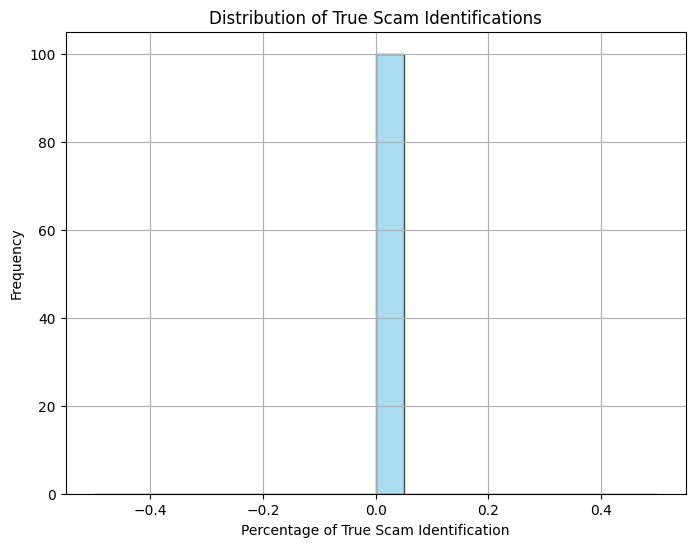

{'average_train_silhouette_score': np.float64(0.99),
 'std_train_silhouette_score': np.float64(0.0),
 'average_train_inertia': np.float64(4.79),
 'std_train_inertia': np.float64(0.97),
 'average_train_davies_bouldin_index': np.float64(0.64),
 'std_train_davies_bouldin_index': np.float64(0.11),
 'average_train_perc_true_scams_identified': np.float64(0.0),
 'std_train_perc_true_scams_identified': np.float64(0.0),
 'average_test_silhouette_score': np.float64(0.99),
 'std_test_silhouette_score': np.float64(0.0),
 'average_test_inertia': np.float64(1.54),
 'std_test_inertia': np.float64(0.9),
 'average_test_davies_bouldin_index': np.float64(0.3),
 'std_test_davies_bouldin_index': np.float64(0.25),
 'average_test_perc_true_scams_identified': np.float64(0.0),
 'std_test_perc_true_scams_identified': np.float64(0.0)}

In [102]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam', 'nonqualified', 'consulting', 'admin', 'strat_research', 'refund_trans', 'total_expenditures', 'uw_page_rank', 'salaries', 'media', 'receipts']

sim_results = cluster_analysis.run_monte_carlo_cluster_model(
    all_scaled_data = scaled_features,
    test_n = 0.3,
    seed = 492,
    features_to_drop = dropped_features,
    n_simulations = 100
)

sim_results

#### Model with no Outliers and all Features

In [103]:
columns_to_modify = ['total_expenditures', 'admin', 'campaign', 'fundraising', 'media', 
           'refund_trans', 'contrib_trans', 'strat_research', 'unclassifiable', 'consulting',
           'salaries', 'receipts', 'uw_degree', 'uw_eigen', 'uw_eigen_weighted' ,'uw_page_rank', 
           'uw_page_rank_weighted']

no_outliers = cluster_analysis.remove_outliers( 
    all_scaled_data = scaled_features,
    columns = columns_to_modify
)

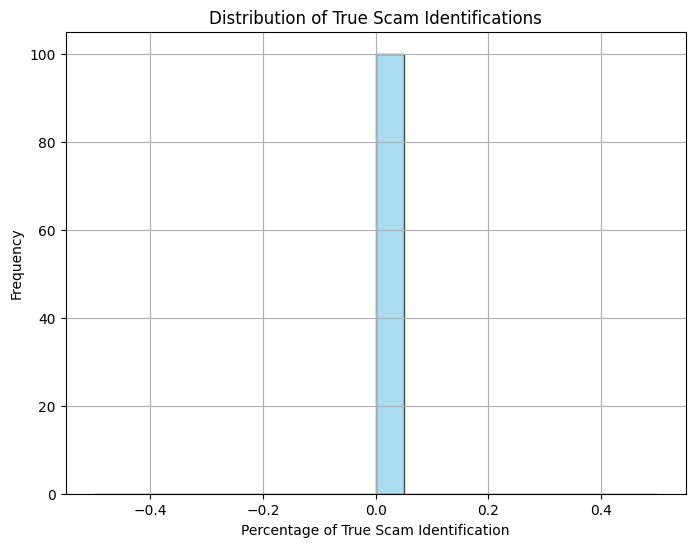

{'average_train_silhouette_score': np.float64(1.0),
 'std_train_silhouette_score': np.float64(0.0),
 'average_train_inertia': np.float64(0.87),
 'std_train_inertia': np.float64(0.21),
 'average_train_davies_bouldin_index': np.float64(0.01),
 'std_train_davies_bouldin_index': np.float64(0.0),
 'average_train_perc_true_scams_identified': np.float64(0.0),
 'std_train_perc_true_scams_identified': np.float64(0.0),
 'average_test_silhouette_score': np.float64(1.0),
 'std_test_silhouette_score': np.float64(0.0),
 'average_test_inertia': np.float64(0.42),
 'std_test_inertia': np.float64(0.21),
 'average_test_davies_bouldin_index': np.float64(0.01),
 'std_test_davies_bouldin_index': np.float64(0.0),
 'average_test_perc_true_scams_identified': np.float64(0.0),
 'std_test_perc_true_scams_identified': np.float64(0.0)}

In [104]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam']

sim_results = cluster_analysis.run_monte_carlo_cluster_model(
    all_scaled_data = no_outliers,
    test_n = 0.3,
    seed = 492,
    features_to_drop = dropped_features,
    n_simulations = 100
)

sim_results

#### Model with no outliers and all correlated featuers are removed

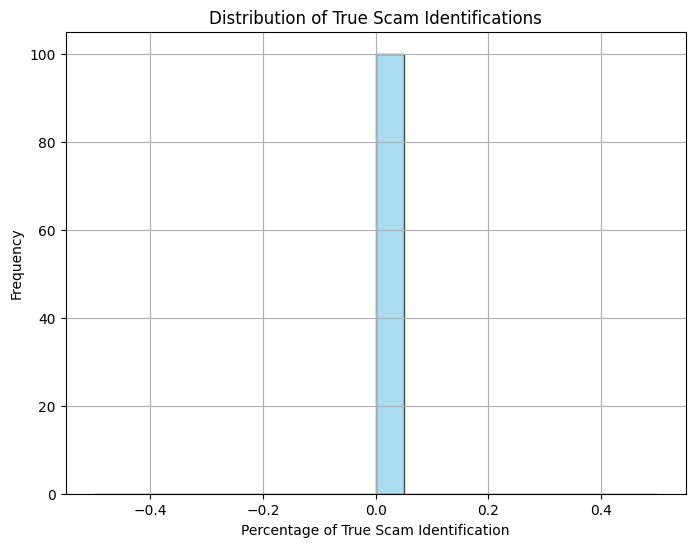

{'average_train_silhouette_score': np.float64(0.99),
 'std_train_silhouette_score': np.float64(0.0),
 'average_train_inertia': np.float64(0.13),
 'std_train_inertia': np.float64(0.03),
 'average_train_davies_bouldin_index': np.float64(0.21),
 'std_train_davies_bouldin_index': np.float64(0.1),
 'average_train_perc_true_scams_identified': np.float64(0.0),
 'std_train_perc_true_scams_identified': np.float64(0.0),
 'average_test_silhouette_score': np.float64(0.99),
 'std_test_silhouette_score': np.float64(0.01),
 'average_test_inertia': np.float64(0.05),
 'std_test_inertia': np.float64(0.03),
 'average_test_davies_bouldin_index': np.float64(0.18),
 'std_test_davies_bouldin_index': np.float64(0.17),
 'average_test_perc_true_scams_identified': np.float64(0.0),
 'std_test_perc_true_scams_identified': np.float64(0.0)}

In [105]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam', 'nonqualified', 'consulting', 'admin', 'strat_research', 'refund_trans', 'total_expenditures', 'uw_page_rank', 'salaries', 'media', 'receipts']

sim_results = cluster_analysis.run_monte_carlo_cluster_model(
    all_scaled_data = no_outliers,
    test_n = 0.3,
    seed = 492,
    features_to_drop = dropped_features,
    n_simulations = 100
)

sim_results

### Isolation Forests

1. Model with all features (not including categorical but does include binary).
2. Model with all features (categorial and binary)

**See ML Updates for results summary**
  

##### Model with all features (including binary)

In [106]:
isolation_analysis = isolation_forest_analysis(all_scaled_data = scaled_features, scam_PAC_names = scam_PACs)

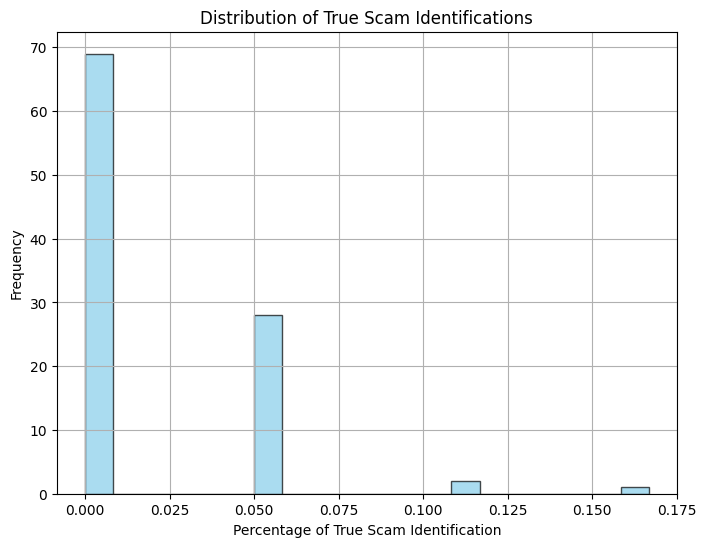

{'average_train_silhouette_score': np.float64(0.8044950678856311),
 'std_train_silhouette_score': np.float64(0.001096860971995324),
 'average_train_davies_bouldin_score': np.float64(0.3829156654464918),
 'std_train_davies_bouldin_score': np.float64(0.012140033186367711),
 'average_ks_stat_train': np.float64(1.0),
 'std_ks_stat_train': np.float64(0.0),
 'average_ks_pvalue_train': np.float64(1.7894122084393278e-249),
 'std_ks_pvalue_train': np.float64(0.0),
 'average_train_true_scam_identifications': np.float64(0.01714285714285714),
 'std_train_true_scam_identifications': np.float64(0.012177820811947068),
 'average_test_silhouette_score': np.float64(0.8046212446568805),
 'std_test_silhouette_score': np.float64(0.0024802274614065508),
 'average_test_davies_bouldin_score': np.float64(0.3758446601194974),
 'std_test_davies_bouldin_score': np.float64(0.027321988040345694),
 'average_ks_stat_test': np.float64(1.0),
 'std_ks_stat_test': np.float64(0.0),
 'average_ks_pvalue_test': np.float64(1.

In [107]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam']

sim_results = isolation_analysis.run_isolation_forest_monte_carlo(
    prob = 0.05,
    seed = 498,
    test_size = 0.3,
    features_to_drop = dropped_features,
    all_scaled_data = scaled_features,
    n_simulations = 100
)

sim_results

##### Model with all features, including binary and categorical

In [108]:
unique_categoires = scaled_features['CMTE_DSGN'].unique()
scaled_features_copy = scaled_features.copy()

for category in unique_categoires:
    scaled_features_copy.loc[:, f'CMTE_DSGN_{category}'] = (scaled_features_copy['CMTE_DSGN'] == category).astype(int)

In [109]:
unique_categoires_TP = scaled_features_copy['CMTE_TP'].unique()

for category in unique_categoires_TP:
    scaled_features_copy.loc[:, f'CMTE_TP_{category}'] = (scaled_features_copy['CMTE_TP'] == category).astype(int)

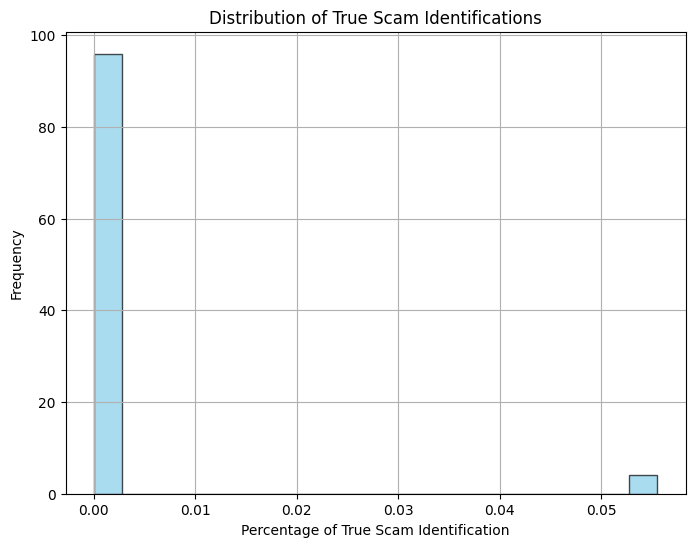

{'average_train_silhouette_score': np.float64(0.44261917116076743),
 'std_train_silhouette_score': np.float64(0.0015728544841802788),
 'average_train_davies_bouldin_score': np.float64(1.053399996123815),
 'std_train_davies_bouldin_score': np.float64(0.015462787814060205),
 'average_ks_stat_train': np.float64(1.0),
 'std_ks_stat_train': np.float64(0.0),
 'average_ks_pvalue_train': np.float64(5.849205262781165e-193),
 'std_ks_pvalue_train': np.float64(0.0),
 'average_train_true_scam_identifications': np.float64(0.002857142857142857),
 'std_train_true_scam_identifications': np.float64(0.00773717943298663),
 'average_test_silhouette_score': np.float64(0.44196237786347126),
 'std_test_silhouette_score': np.float64(0.0038425434675067524),
 'average_test_davies_bouldin_score': np.float64(1.0525866102599724),
 'std_test_davies_bouldin_score': np.float64(0.029106927688340667),
 'average_ks_stat_test': np.float64(1.0),
 'std_ks_stat_test': np.float64(0.0),
 'average_ks_pvalue_test': np.float64(4

In [110]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam']

sim_results = isolation_analysis.run_isolation_forest_monte_carlo(
    prob = 0.05,
    seed = 498,
    test_size = 0.3,
    features_to_drop = dropped_features,
    all_scaled_data = scaled_features_copy,
    n_simulations = 100
)

sim_results

##### Model with highly correlated featured removed. No categorical variables. 

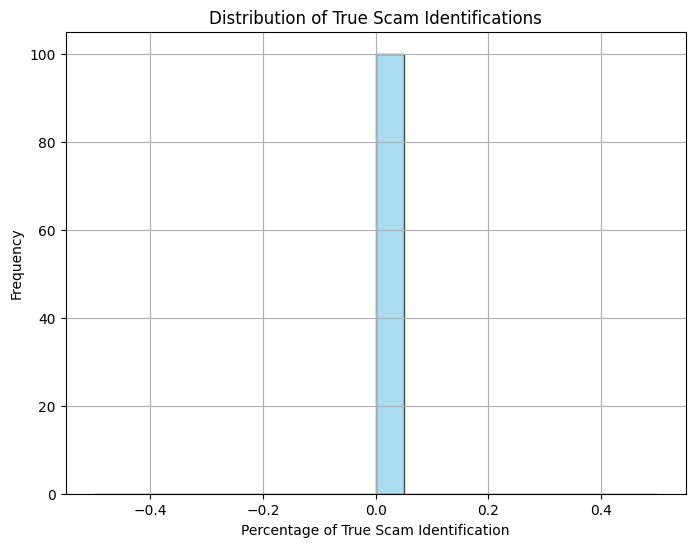

{'average_train_silhouette_score': np.float64(0.9810741446798518),
 'std_train_silhouette_score': np.float64(0.0007138462080109128),
 'average_train_davies_bouldin_score': np.float64(0.08269497112896335),
 'std_train_davies_bouldin_score': np.float64(0.005826022103823981),
 'average_ks_stat_train': np.float64(1.0),
 'std_ks_stat_train': np.float64(0.0),
 'average_ks_pvalue_train': np.float64(2.2504113411498066e-246),
 'std_ks_pvalue_train': np.float64(0.0),
 'average_train_true_scam_identifications': np.float64(0.0004761904761904762),
 'std_train_true_scam_identifications': np.float64(0.003333333333333333),
 'average_test_silhouette_score': np.float64(0.9810796376138708),
 'std_test_silhouette_score': np.float64(0.0008986644319297029),
 'average_test_davies_bouldin_score': np.float64(0.08087114737512487),
 'std_test_davies_bouldin_score': np.float64(0.01321010674273542),
 'average_ks_stat_test': np.float64(1.0),
 'std_ks_stat_test': np.float64(0.0),
 'average_ks_pvalue_test': np.float6

In [111]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam', 'nonqualified', 'consulting', 'admin', 'strat_research', 'refund_trans', 'total_expenditures', 'uw_page_rank', 'salaries', 'media', 'receipts']

sim_results = isolation_analysis.run_isolation_forest_monte_carlo(
    prob = 0.05,
    seed = 498,
    test_size = 0.3,
    features_to_drop = dropped_features,
    all_scaled_data = scaled_features,
    n_simulations = 100
)

sim_results

##### Model with graph metrics remvoed, excluding binary and categorical variables

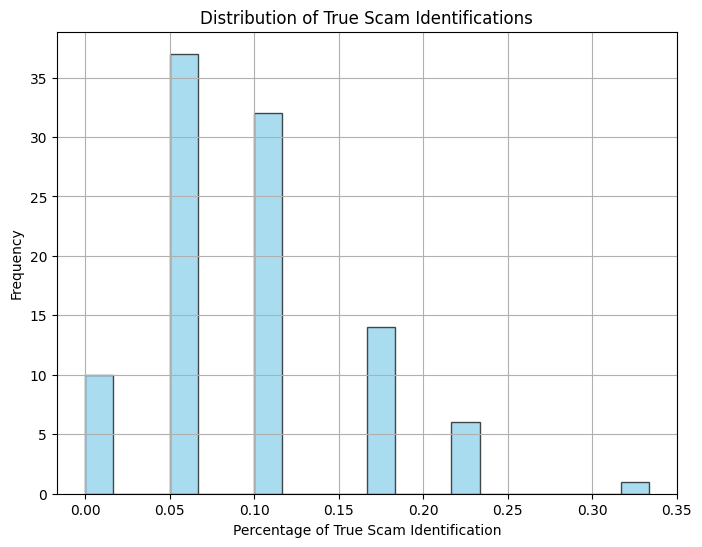

{'average_train_silhouette_score': np.float64(0.9819570126856653),
 'std_train_silhouette_score': np.float64(0.0007393903546048051),
 'average_train_davies_bouldin_score': np.float64(0.09486207520717813),
 'std_train_davies_bouldin_score': np.float64(0.00767249026448638),
 'average_ks_stat_train': np.float64(1.0),
 'std_ks_stat_train': np.float64(0.0),
 'average_ks_pvalue_train': np.float64(3.2921032900332236e-260),
 'std_ks_pvalue_train': np.float64(0.0),
 'average_train_true_scam_identifications': np.float64(0.08642857142857142),
 'std_train_true_scam_identifications': np.float64(0.03293210909619682),
 'average_test_silhouette_score': np.float64(0.9819706476515776),
 'std_test_silhouette_score': np.float64(0.0009979008495109231),
 'average_test_davies_bouldin_score': np.float64(0.0912961527872627),
 'std_test_davies_bouldin_score': np.float64(0.017013699423742326),
 'average_ks_stat_test': np.float64(1.0),
 'std_ks_stat_test': np.float64(0.0),
 'average_ks_pvalue_test': np.float64(8.

In [ ]:
dropped_features  = ['CMTE_TP', 'CMTE_DSGN', 'CMTE_NM', 'is_known_scam', 'nonqualified', 'uw_degree', 'uw_eigen', 'uw_eigen_weighted', 'uw_page_rank', 'uw_page_rank_weighted']

sim_results = isolation_analysis.run_isolation_forest_monte_carlo(
    prob = 0.05,
    seed = 498,
    test_size = 0.3,
    features_to_drop = dropped_features,
    all_scaled_data = scaled_features,
    n_simulations = 100
)

sim_results

### Anomaly Scores and Red Flag Summary Statistics

In [123]:
# Extract the avg anomaly scores and std dev from the simulation results
df1 = pd.DataFrame(list(sim_results['avg_anomaly_scores'].items()), columns=['CRPFilerid', 'avg_anomaly_scores']).set_index('CRPFilerid')
df2 = pd.DataFrame(list(sim_results['std_dev_anomaly_scores'].items()), columns=['CRPFilerid', 'std_dev_anomaly_scores']).set_index('CRPFilerid')

# Combine the averages and std devs
merged_df = pd.merge(df1, df2, left_index=True, right_index=True)

In [ ]:
# Find +/- standard deviations and the range between the +/- standard deviation
merged_df['plus_one_std'] = merged_df['avg_anomaly_scores'] + merged_df['std_dev_anomaly_scores'] 
merged_df['minus_one_std'] = merged_df['avg_anomaly_scores'] - merged_df['std_dev_anomaly_scores']
merged_df['range'] = merged_df['plus_one_std'] - merged_df['minus_one_std']


In [ ]:
# Find the threshold which is the avg score - 3 standard deviations
threshold = merged_df['avg_anomaly_scores'].mean() - (3 * merged_df['avg_anomaly_scores'].std())

In [ ]:
import numpy as np
# Label the PACs as a scam if it below the threshold
merged_df['labels'] = np.where(merged_df['minus_one_std'] < threshold, -1, 1)
merged_df['is_scam'] = np.where(merged_df['labels'] == -1, 1, 0) #1 = likey a scam, 0 = not scam


In [ ]:
# Counting how many are labeled as a scam
cross_tab = pd.crosstab(merged_df['is_scam'], columns = 'count')

In [ ]:
# Need the features to get precision stats and red flag stats
result = pd.merge(merged_df, network_features, on = 'CRPFilerid', how = 'left')

In [ ]:
result['is_known_scam'] = result['CMTE_NM'].isin(cap_scam_PACs).astype(int)

In [ ]:
# Comparison of known scams to scams
cross_tab = pd.crosstab(result['is_scam'], result['is_known_scam'])
cross_tab

In [ ]:
# Nonqualifed vs qualified for known scam
cross_tab = pd.crosstab(result['nonqualified'], result['is_known_scam'])
cross_tab

In [ ]:
# Percentages of expenditures
dividing_cols =  ['total_expenditures', 'admin', 'campaign', 'fundraising', 'media', 'refund_trans', 
                  'contrib_trans', 'strat_research', 'unclassifiable', 'consulting', 'salaries', 'receipts']

result[dividing_cols] = result[dividing_cols].div(result['total_expenditures'], axis = 0) * 100

In [ ]:
# Summary stats / red flags for knowns vs not scams
group_summary = result.groupby('is_known_scam').agg({
    'fundraising' : ['median', 'mean', 'std'],
    'contrib_trans' : ['median', 'mean', 'std'],
    'salaries' : ['median', 'mean', 'std'],
    'unclassifiable' : ['median', 'mean', 'std'],
    'consulting' : ['median', 'mean', 'std'],
    'strat_research' : ['median', 'mean', 'std'],
    'refund_trans' : ['median', 'mean', 'std'],
    'media' : ['median', 'mean', 'std'],
    'campaign' : ['median', 'mean', 'std'],
    'admin' : ['median', 'mean', 'std'],
    'uw_degree' : ['median', 'mean', 'std'],
    'uw_eigen' : ['median', 'mean', 'std'],
    'uw_eigen_weighted' : ['median', 'mean', 'std'],
    'uw_page_rank' : ['median', 'mean', 'std'],
    'uw_page_rank_weighted' : ['median', 'mean', 'std']
    })
group_summary = group_summary
group_summary

In [ ]:
scam_scores = result[['is_scam']]
scam_scores.to_csv("scam_scores.csv")